 **## Importando las bibliotecas necesarias**

In [132]:
# Importando bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

**## Recopilación de datos**

In [133]:
# cargando datos

df = pd.read_csv('/datos_tratados.csv')
df.head()


,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


In [134]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


In [135]:

df.shape

(7043, 22)

In [136]:
df.columns

Index(['CustomerID', 'Churn', 'Gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'Tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'ChargesDaily', 'ChargesMonthly',
       'ChargesTotal'],
      dtype='object')

**📌 Pre-Procesamiento de datos**

**Eliminación de columnas irrelevantes**

In [137]:

df = df.drop(columns=["CustomerID"])
df.head()

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,No,Male,No,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,Yes,Male,No,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


**✔️ Agrupación de No y No servicio**

In [138]:
cols_to_fix = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in cols_to_fix:
    df[col] = df[col].replace( 'No internet service', 'No')


**✔️ Comprobación de valores nulos**

In [139]:
df.isnull().sum()

,0
Churn,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


**Correlación entre variables numéricas**

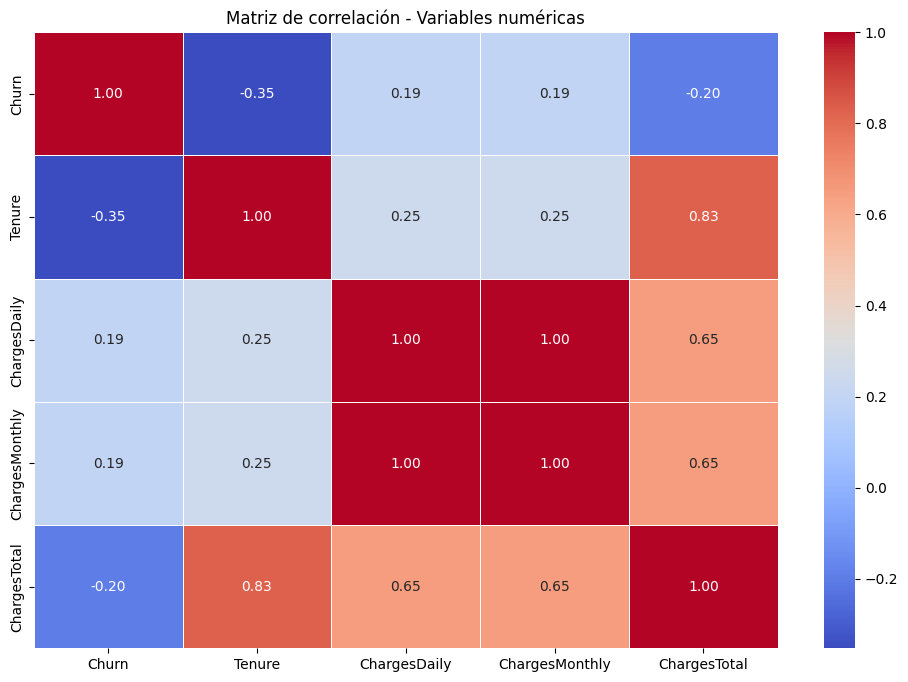

In [140]:
# Copiar dataframe para evitar warning
df_corr = df.copy()

# Converter Churn en numérico
df_corr["Churn"] = df_corr["Churn"].map({"Yes": 1, "No": 0})

# Seleccionar solo variables numéricas (incluyendo Churn ya convertidas)
df_numeric = df_corr.select_dtypes(include=["int64", "float64"])

# Calcular la matriz de correlación
corr_matrix = df_numeric.corr()

# Mapa de calor de la trama
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de correlación - Variables numéricas")
plt.show()

**Análisis específicos**

In [141]:
# Ptasa de deserción

px.histogram(df, x = 'Churn', text_auto = True)

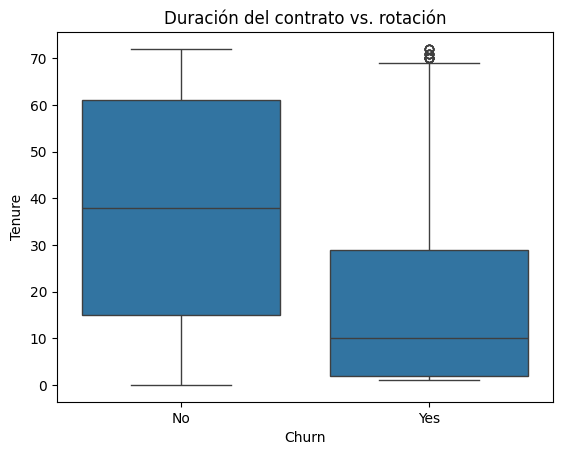

In [142]:

# Relación entre la duración del contrato y la rotación de personal

plt.figure()
sns.boxplot(x='Churn', y='Tenure', data=df)
plt.title('Duración del contrato vs. rotación')
plt.show()

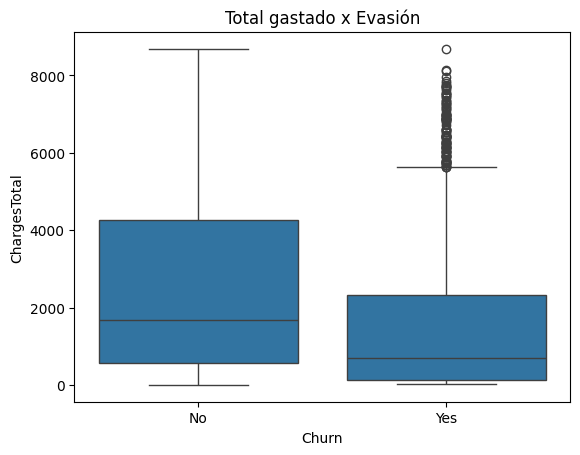

In [143]:
# Total gastado x Evasión

plt.figure()
sns.boxplot(x='Churn', y='ChargesTotal', data=df)
plt.title('Total gastado x Evasión')
plt.show()


**Tabla de proporción de evasión por categoría**

In [144]:
## Comprobando la proporción de abandono

# Recuento total
df['Churn'].value_counts()

# Proporción porcentual
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


In [145]:
categorical_cols = df.select_dtypes(include=["object"]).columns
categorical_cols = categorical_cols.drop("Churn")

In [146]:
for col in categorical_cols:
    print(f"\n📌  Análisis de la variable:{col}")
   #Crea una tabla con el porcentaje de abandono (churn) dentro de cada categoría de una variable.
    display(pd.crosstab(df[col], df["Churn"], normalize="index") * 100)



📌  Análisis de la variable:Gender


Churn,No,Yes
Gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338



📌  Análisis de la variable:SeniorCitizen


Churn,No,Yes
SeniorCitizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261



📌  Análisis de la variable:Partner


...

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858



📌  Análisis de la variable:PaperlessBilling


Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092



📌  Análisis de la variable:PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


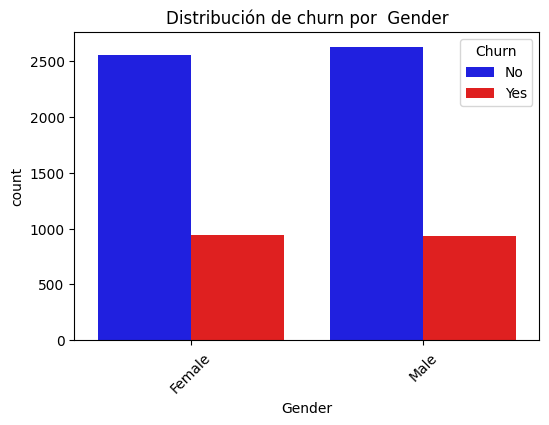

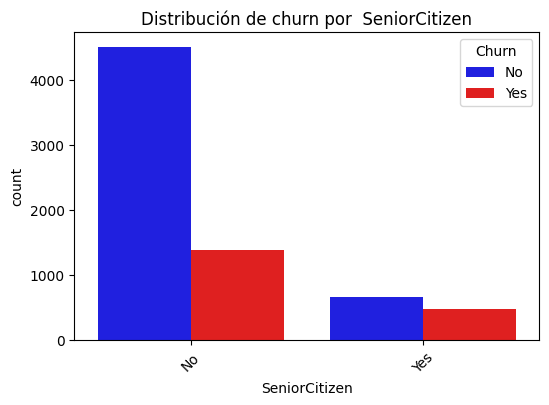

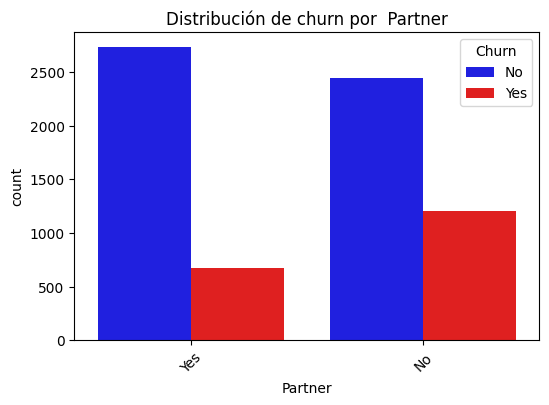

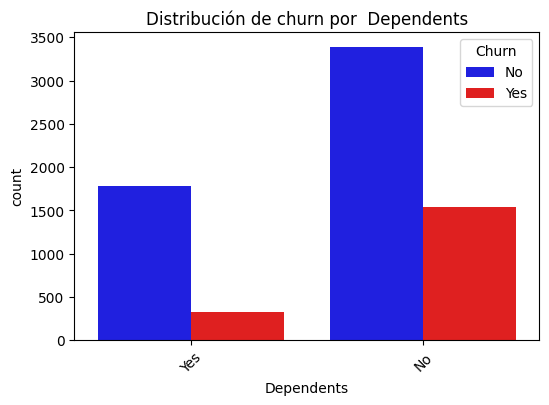

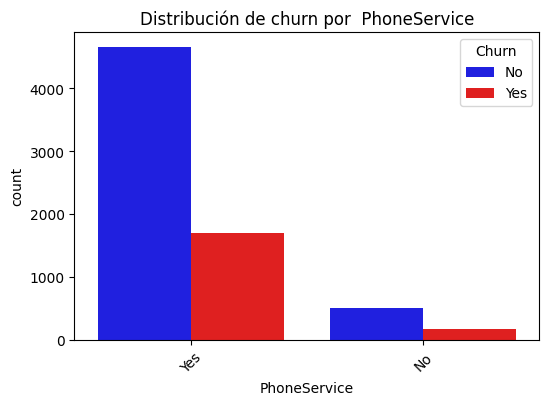

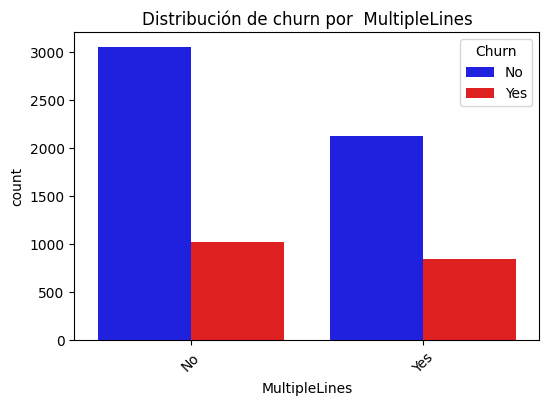

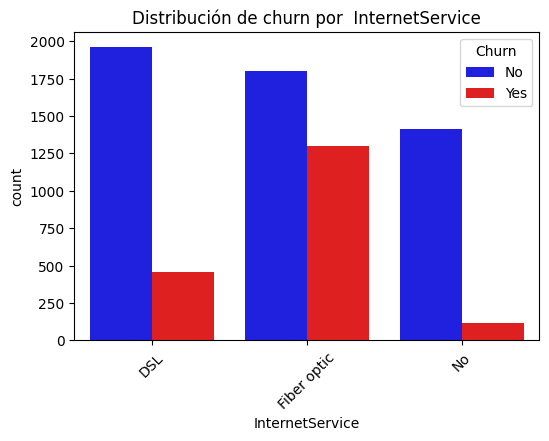

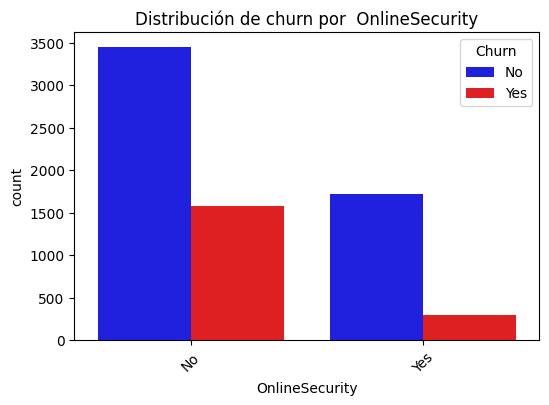

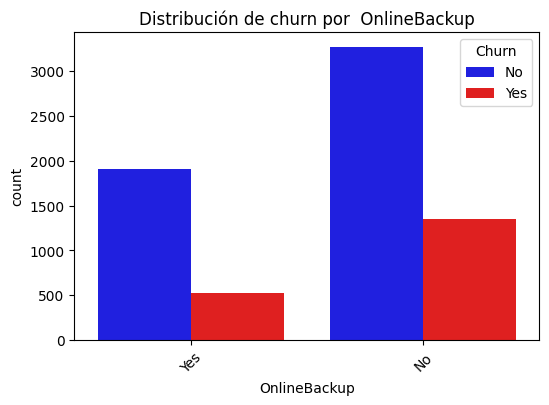

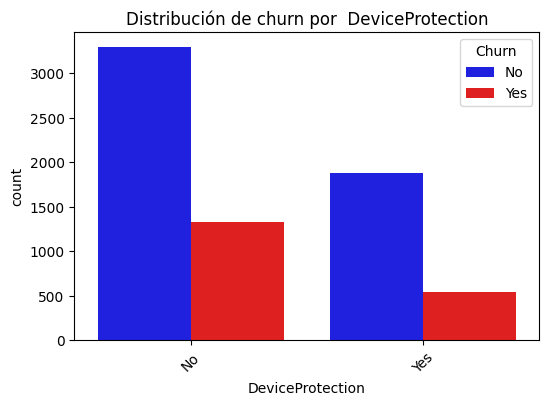

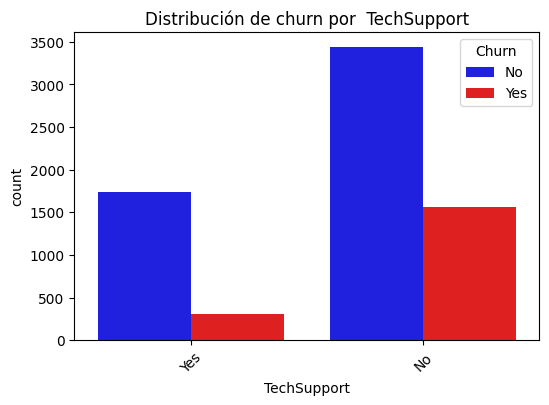

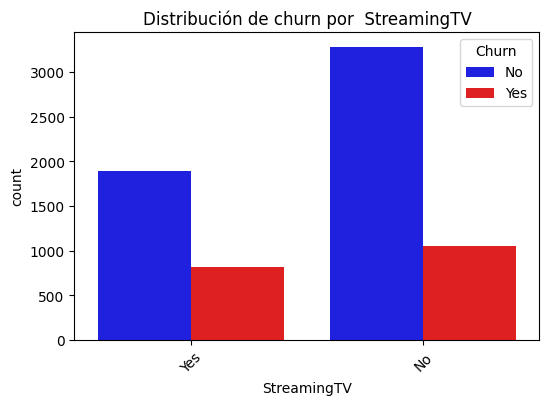

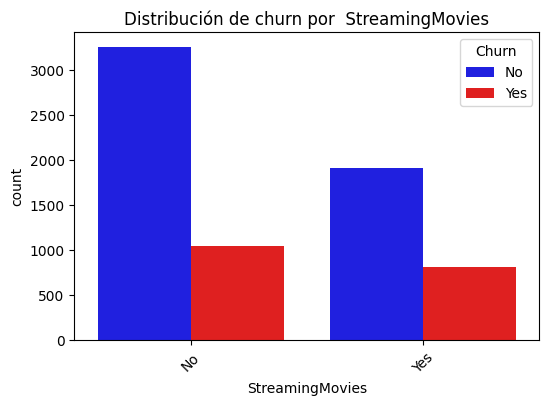

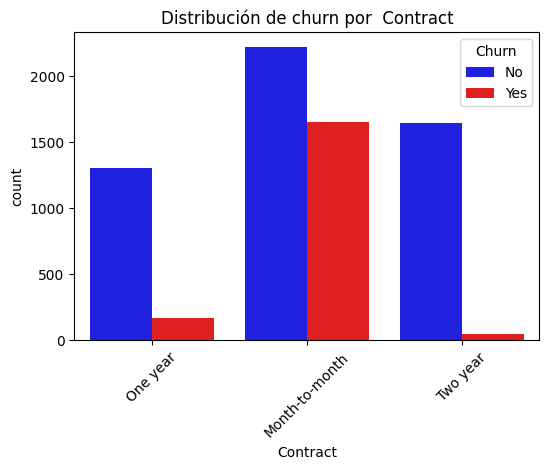

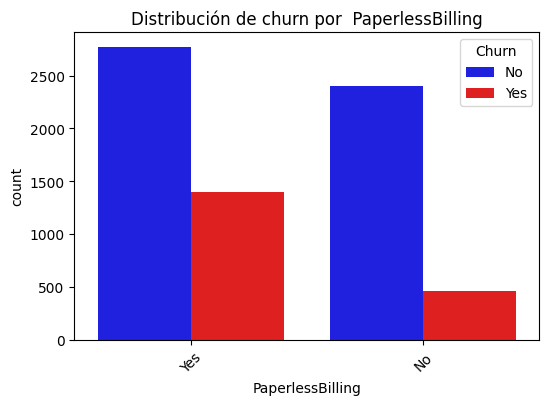

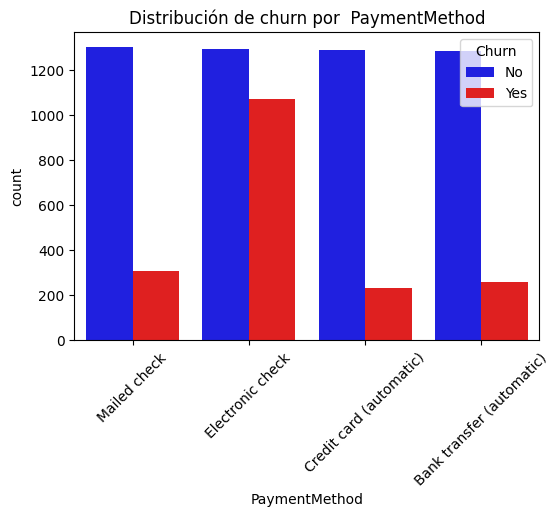

In [147]:

palette = {"No": "blue", "Yes": "red"}

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(
        data=df,
        x=col,
        hue="Churn",
        palette=palette
    )
    plt.title(f"Distribución de churn por  {col}")
    plt.xticks(rotation=45)
    plt.show()

**Separación de datos / Codificación**

# **Variables explicativas y variable objetivo**
Para realizar la predicción de valores con un modelo de aprendizaje automático, debemos separar la variable objetivo y las variables explicativas. La y representa la variable que queremos predecir, mientras que la x representa todas las variables que se utilizarán para explicar el comportamiento de la y.

In [148]:
# x = variable explicativa
# y = variable objetivo (churn)

x = df.drop(columns='Churn', axis = 1)
y = df['Churn']

In [149]:
x

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,Female,No,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.60,593.30
1,Male,No,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.90,542.40
2,Male,No,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.90,280.85
3,Male,Yes,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.00,1237.85
4,Female,Yes,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Female,No,No,No,13,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,1.84,55.15,742.90
7039,Male,No,Yes,No,22,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,2.84,85.10,1873.70
7040,Male,No,No,No,2,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,1.68,50.30,92.75
7041,Male,No,Yes,Yes,67,Yes,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,2.26,67.85,4627.65


In [150]:
y

,Churn
0,No
1,No
2,Yes
3,Yes
4,Yes
...,...
7038,No
7039,Yes
7040,No
7041,No


# **Transformando las variables explicativas**

Los algoritmos de aprendizaje automático no comprenden datos en formato de texto, por lo que debemos transformar los datos al formato numérico para que el algoritmo pueda comprender la información. Esta transformación debe realizarse de manera que no altere la información original del conjunto de datos, por lo que no basta con cambiar los valores por valores numéricos aleatorios.

In [151]:
colunas = x.columns

one_hot = make_column_transformer((
    OneHotEncoder(drop = 'if_binary'), ['Gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
),
    remainder = 'passthrough',
    sparse_threshold=0,
    verbose_feature_names_out=False)

In [152]:
x = one_hot.fit_transform(x)
colunas = one_hot.get_feature_names_out(colunas)
colunas

array(['Gender_Male', 'SeniorCitizen_Yes', 'Partner_Yes',
       'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_Yes',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_Yes', 'OnlineBackup_Yes',
       'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes',
       'StreamingMovies_Yes', 'Contract_Month-to-month',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Tenure', 'ChargesDaily', 'ChargesMonthly', 'ChargesTotal'],
      dtype=object)

In [153]:
pd.DataFrame(x, columns=colunas)

,Gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,...,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Tenure,ChargesDaily,ChargesMonthly,ChargesTotal
0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,9.0,2.19,65.60,593.30
1,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,9.0,2.00,59.90,542.40
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,4.0,2.46,73.90,280.85
3,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,13.0,3.27,98.00,1237.85
4,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,3.0,2.80,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,13.0,1.84,55.15,742.90
7039,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,22.0,2.84,85.10,1873.70
7040,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,2.0,1.68,50.30,92.75
7041,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,67.0,2.26,67.85,4627.65


In [154]:
label_encoder = LabelEncoder()
y  = label_encoder.fit_transform(y)
y


array([0, 0, 1, ..., 0, 0, 0])

# **Ajustando modelos**
**Dividir los datos entre entrenamiento y prueba**

Para comprender si el modelo realmente está aprendiendo con los datos, debemos separar los datos entre entrenamiento y prueba. Los datos de entrenamiento se utilizan para ajustar el modelo, mientras que los datos de prueba sirven para verificar el aprendizaje del modelo en datos que no se utilizaron en el momento del ajuste.

In [155]:
x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.2, stratify = y,  random_state = 42)

# **Normalización**


In [156]:
scaler = StandardScaler()


In [157]:
x_treino_normalizado = scaler.fit_transform(x_treino)
x_teste_normalizado = scaler.transform(x_teste)

In [158]:
normalizacion = MinMaxScaler()
x_treino_normalizado = normalizacion.fit_transform(x_treino)

In [159]:
pd.DataFrame(x_treino_normalizado)


,0,1,2,3,4,5,6,7,8,9,...,17,18,19,20,21,22,23,24,25,26
0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.833333,0.755224,0.754360,0.630515
1,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.166667,0.008955,0.009467,0.024445
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.027778,0.617910,0.618336,0.015786
3,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.458333,0.561194,0.561535,0.282482
4,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.194444,0.674627,0.673642,0.134033
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.305556,0.023881,0.023418,0.052085
5630,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.583333,0.755224,0.755356,0.482026
5631,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.277778,0.665672,0.666168,0.199717
5632,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.333333,0.062687,0.062780,0.065833


# **Modelo de base**
El modelo más sencillo para clasificar los datos consiste simplemente en utilizar un algoritmo que asigna todas las clasificaciones a la clase que tiene mayor frecuencia. Este algoritmo sirve como criterio de comparación para identificar si los demás modelos tienen un rendimiento mejor que la clasificación más sencilla posible.

In [160]:
dummy = DummyClassifier(random_state=42)
dummy.fit(x_treino, y_treino)

y_pred_dummy = dummy.predict(x_teste)

print(classification_report(y_teste, y_pred_dummy, zero_division=0))

# dummy.score(x_teste, y_teste)

              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1035
           1       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409



In [161]:
print("Accuracy Dummy:", accuracy_score(y_teste, y_pred_dummy))

Accuracy Dummy: 0.7345635202271115


# **Árbol de decisión**
El modelo de árbol de decisión se utiliza mucho por su alta explicabilidad y rápido procesamiento, manteniendo un rendimiento muy interesante.

Se basa en decisiones simples tomadas por el algoritmo, separando los datos en función de comparaciones de menor y mayor en los valores de las columnas de la base de datos.

In [162]:
tree_model = DecisionTreeClassifier(
        max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42)

tree_model.fit(x_treino, y_treino)

tree_pred = tree_model.predict(x_teste)

print(classification_report(y_teste, tree_pred))


              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1035
           1       0.58      0.49      0.53       374

    accuracy                           0.77      1409
   macro avg       0.70      0.68      0.69      1409
weighted avg       0.76      0.77      0.76      1409



In [163]:
print("Accuracy Árvore:", accuracy_score(y_teste, tree_pred))

Accuracy Árvore: 0.7693399574166075


In [164]:

nome_colunas = [
    'Gender_Male', 'SeniorCitizen_Yes', 'Partner_Yes',
       'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_Yes',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_Yes', 'OnlineBackup_Yes',
       'DeviceProtection_Yes', 'TechSupport_Yes', 'StreamingTV_Yes',
       'StreamingMovies_Yes', 'Contract_Month-to-month',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Tenure', 'ChargesDaily', 'ChargesMonthly', 'ChargesTotal'
]

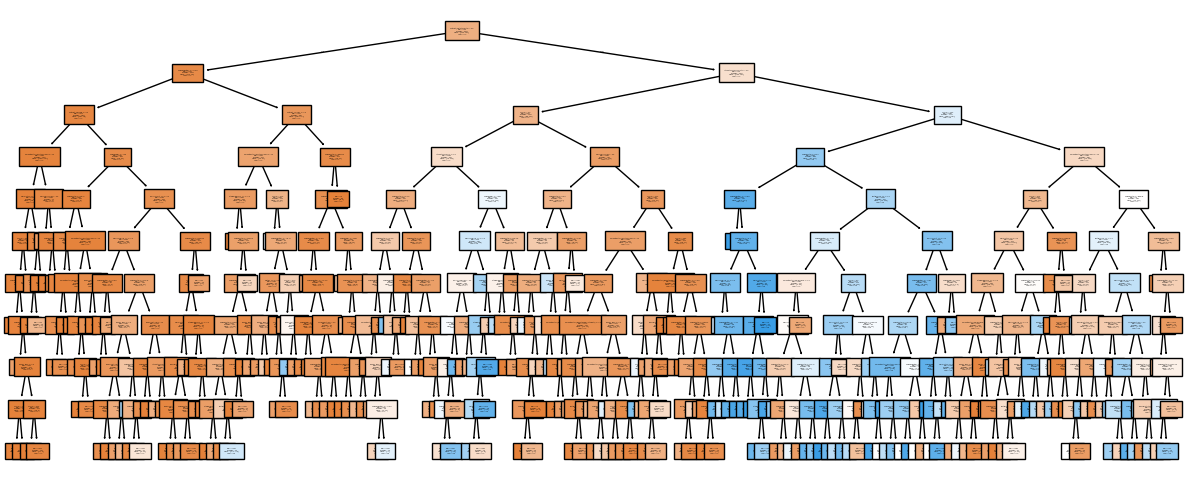

In [165]:
plt.figure(figsize = (15, 6))
plot_tree(tree_model, filled = True, class_names = ['nao', 'sim'], fontsize = 1, feature_names = nome_colunas);

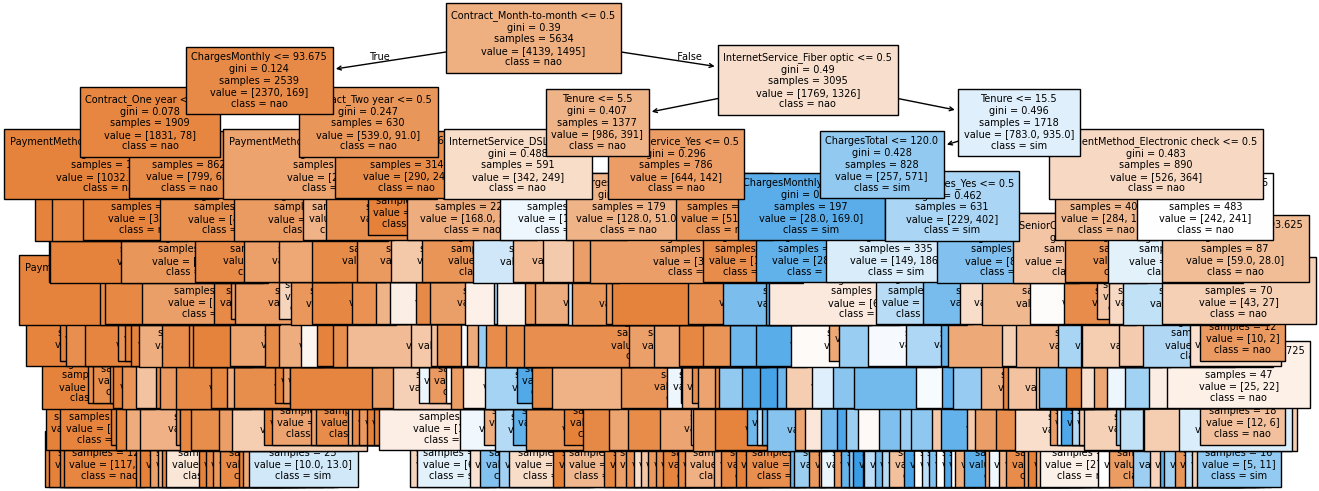

In [166]:
plt.figure(figsize = (15, 6))
plot_tree(tree_model, filled = True, class_names = ['nao', 'sim'], fontsize = 7, feature_names = nome_colunas);


# **Random Forest**

In [167]:
rf_model = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=5, max_features='sqrt', random_state=42)
rf_model.fit(x_treino, y_treino)

y_pred_rf = rf_model.predict(x_teste)

print("Random Forest")
print(classification_report(y_teste, y_pred_rf))


Random Forest
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1035
           1       0.65      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.79      1409



In [168]:
print("Accuracy Random Forest:", accuracy_score(y_teste, y_pred_rf))

Accuracy Random Forest: 0.794889992902768


# **KNN**
El algoritmo KNN se basa en el cálculo de la distancia entre los registros de la base de datos y busca elementos que estén próximos entre sí (vecinos) para tomar la decisión de clasificación.

Debido al uso de cálculos de distancia, este algoritmo se ve influenciado por la escala de las variables y, por ello, es necesario transformar los datos antes de utilizar este método.

In [169]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_treino_normalizado, y_treino)

knn_pred = knn_model.predict(x_teste_normalizado)
print(classification_report(y_teste, knn_pred))

print("KNN:", accuracy_score(y_teste, knn_pred))

              precision    recall  f1-score   support

           0       0.84      0.83      0.84      1035
           1       0.55      0.57      0.56       374

    accuracy                           0.76      1409
   macro avg       0.70      0.70      0.70      1409
weighted avg       0.76      0.76      0.76      1409

KNN: 0.7608232789212207


In [170]:
print("Accuracy KNN:", accuracy_score(y_teste, knn_pred))

Accuracy KNN: 0.7608232789212207


# **Regresión logística**

In [171]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(x_treino, y_treino)

y_pred_log_normal = log_model.predict(x_teste)

print("Regrsion Logística")
print(classification_report(y_teste, y_pred_log_normal))

Regrsion Logística
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



In [172]:
print("Accuracy Regresion Logística Normalizado:", accuracy_score(y_teste, y_pred_log_normal))

Accuracy Regresion Logística Normalizado: 0.7913413768630234


In [173]:
log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(x_treino, y_treino)

y_pred_log = log_model.predict(x_teste)

print(classification_report(y_teste, y_pred_log))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



In [174]:
print("Accuracy Regresion Logística:", accuracy_score(y_teste, y_pred_log))

Accuracy Regresion Logística: 0.7395315826827538


# **Evaluación de los modelos**

In [177]:
# Verificando la precisión de los modelos

print("Accuracy Dummy:", accuracy_score(y_teste, y_pred_dummy))
print("Accuracy Árvore:", accuracy_score(y_teste, tree_pred))
print("Accuracy Random Forest:", accuracy_score(y_teste, y_pred_rf))
print("Accuracy KNN:", accuracy_score(y_teste, knn_pred))
print("Accuracy Regresion Logística:", accuracy_score(y_teste, y_pred_log_normal))
print("Accuracy Regresion Logística Normalizado:", accuracy_score(y_teste, y_pred_log))

Accuracy Dummy: 0.7345635202271115
Accuracy Árvore: 0.7693399574166075
Accuracy Random Forest: 0.794889992902768
Accuracy KNN: 0.7608232789212207
Accuracy Regresion Logística: 0.7913413768630234
Accuracy Regresion Logística Normalizado: 0.7395315826827538


In [178]:
# DF com as informações de treino, teste, precisão, recall, f1 e matriz de confusão
# DF con la información de entrenamiento, prueba, precisión, recall, f1 y matriz de confusión.
resultados = []

def avaliar_modelo(nome, modelo, X_train, X_test, y_train, y_test):

    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)

    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test)
    recall = recall_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test)

    print(f"\n===== {nome} =====")
    print(f"Acurácia Treino: {acc_train:.4f}")
    print(f"Acurácia Teste:  {acc_test:.4f}")
    print(f"Precisão:        {precision:.4f}")
    print(f"Recall:          {recall:.4f}")
    print(f"F1-Score:        {f1:.4f}")

       # Matriz de Confusion
    cm = confusion_matrix(y_test, y_pred_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Matriz de Confusion - {nome}")
    plt.show()

    resultados.append({
        "Modelo": nome,
        "Acurácia Treino": acc_train,
        "Acurácia Teste": acc_test,
        "Precisão": precision,
        "Recall": recall,
        "F1-Score": f1
    })


===== Árbol de decisión =====
Acurácia Treino: 0.8419
Acurácia Teste:  0.7693
Precisão:        0.5763
Recall:          0.4947
F1-Score:        0.5324


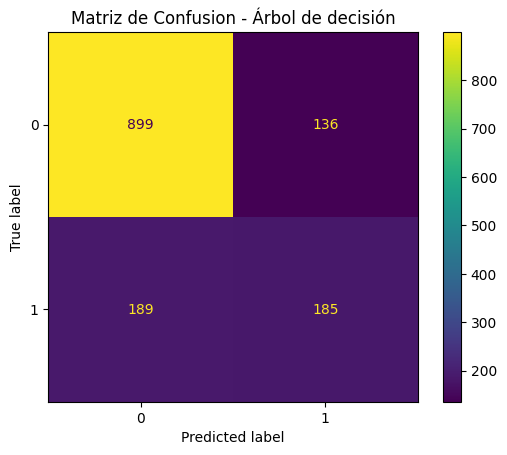


===== Random Forest =====
Acurácia Treino: 0.8490
Acurácia Teste:  0.7949
Precisão:        0.6471
Recall:          0.5000
F1-Score:        0.5641


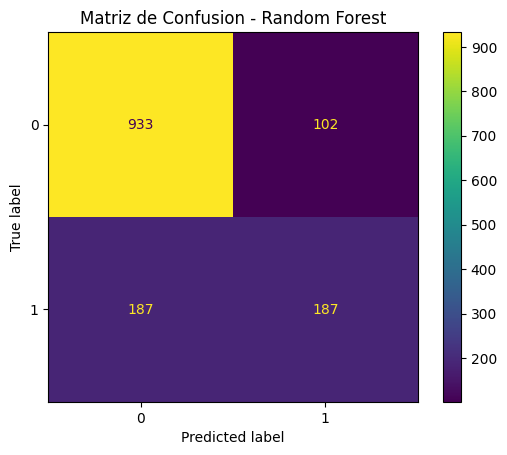


===== KNN =====
Acurácia Treino: 0.8294
Acurácia Teste:  0.7608
Precisão:        0.5473
Recall:          0.5722
F1-Score:        0.5595


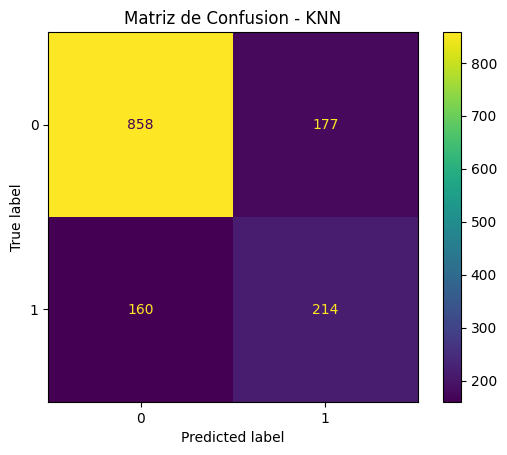


===== Regresión logística =====
Acurácia Treino: 0.7522
Acurácia Teste:  0.7395
Precisão:        0.5060
Recall:          0.7888
F1-Score:        0.6165


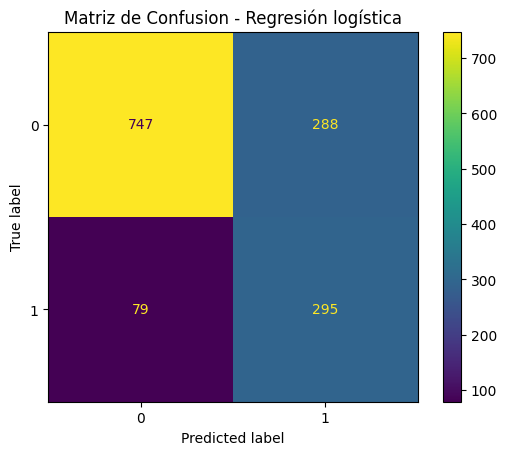

,Modelo,Acurácia Treino,Acurácia Teste,Precisão,Recall,F1-Score
0,Árbol de decisión,0.841853,0.769340,0.576324,0.494652,0.532374
1,Random Forest,0.848953,0.794890,0.647059,0.500000,0.564103
2,KNN,0.829428,0.760823,0.547315,0.572193,0.559477
3,Regresión logística,0.752219,0.739532,0.506003,0.788770,0.616510


In [179]:
resultados = []

# Árbol de decisión
avaliar_modelo(
    "Árbol de decisión",
    tree_model,
    x_treino,
    x_teste,
    y_treino,
    y_teste
)

# Random Forest
avaliar_modelo(
    "Random Forest",
    rf_model,
    x_treino,
    x_teste,
    y_treino,
    y_teste
)


# KNN (usa datos normalizados)
avaliar_modelo(
    "KNN",
    knn_model,
    x_treino_normalizado,
    x_teste_normalizado,
    y_treino,
    y_teste
)

# Regresión logística
avaliar_modelo(
    "Regresión logística",
    log_model,
    x_treino,
    x_teste,
    y_treino,
    y_teste
)

# Crear DataFrame comparativo
df_resultados = pd.DataFrame(resultados)
df_resultados


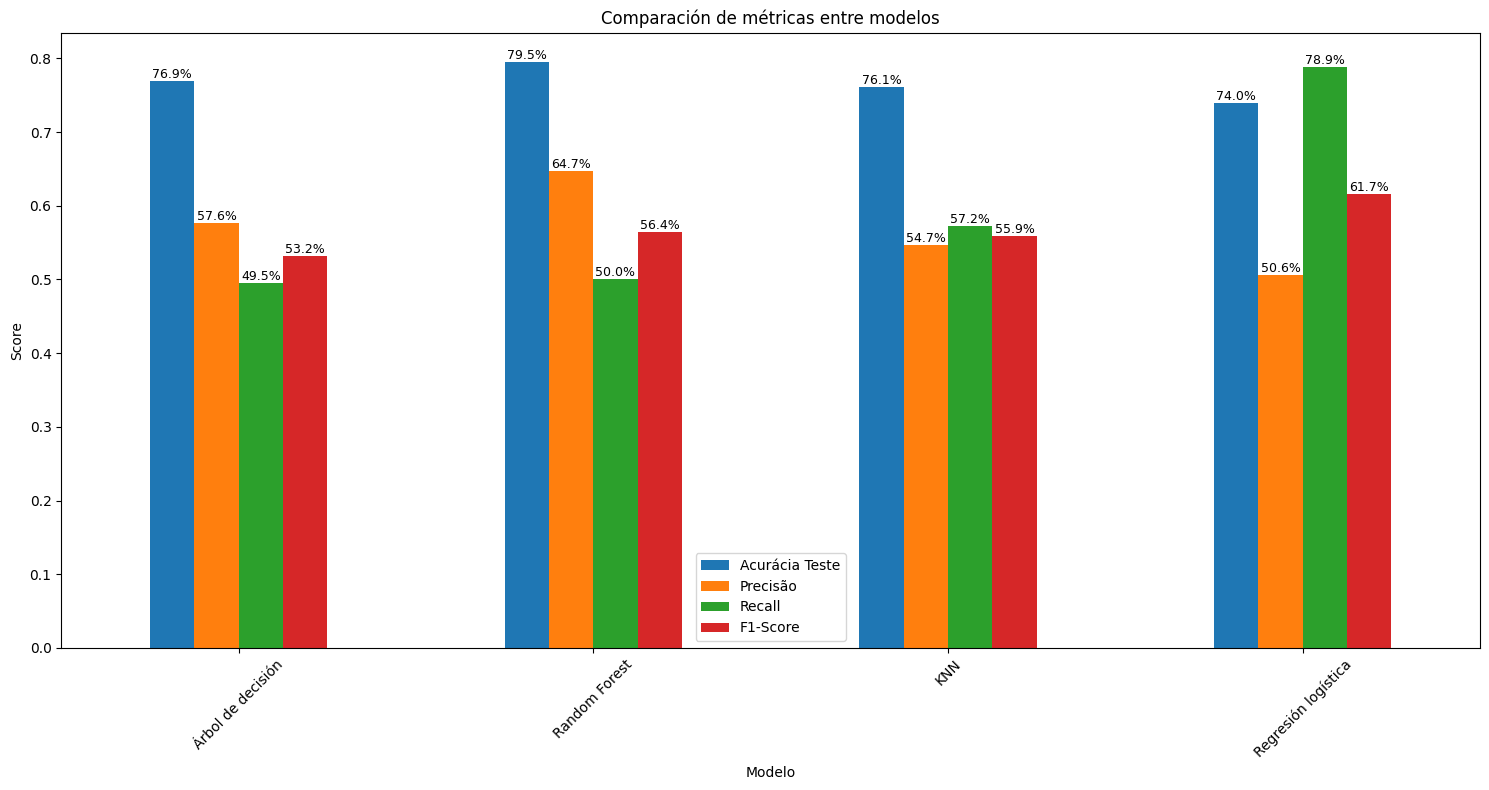

In [181]:
# Gráfico de valoraciones

ax = df_resultados.set_index("Modelo")[[
    "Acurácia Teste", "Precisão", "Recall", "F1-Score"
]].plot(kind="bar", figsize=(15, 8))

plt.title("Comparación de métricas entre modelos")
plt.ylabel("Score")
plt.xticks(rotation=45)

# Añadir porcentaje en las barras
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height*100:.1f}%',  # multiplica por 100 si está entre 0 y 1
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom',
                fontsize=9)

plt.tight_layout()
plt.show()

# **Evaluando por separado para verificar si existe sobreajuste o subajuste.**

In [182]:

#Evaluación – Regresión logística

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Métricas - Teste
acc_log = accuracy_score(y_teste, y_pred_log)
prec_log = precision_score(y_teste, y_pred_log)
rec_log = recall_score(y_teste, y_pred_log)
f1_log = f1_score(y_teste, y_pred_log)
cm_log = confusion_matrix(y_teste, y_pred_log)

print("=== Regresión logística ===")
print("Acurácia:", acc_log)
print("Precisão:", prec_log)
print("Recall:", rec_log)
print("F1-score:", f1_log)
print("Matriz de Confusão:\n", cm_log)

=== Regresión logística ===
Acurácia: 0.7395315826827538
Precisão: 0.5060034305317325
Recall: 0.7887700534759359
F1-score: 0.6165099268547545
Matriz de Confusão:
 [[747 288]
 [ 79 295]]


In [183]:
accuracy_score(y_treino, log_model.predict(x_treino))

0.7522186723464679

In [184]:

#Evaluación – Random Forest

# Métricas - Teste
acc_rf = accuracy_score(y_teste, y_pred_rf)
prec_rf = precision_score(y_teste, y_pred_rf)
rec_rf = recall_score(y_teste, y_pred_rf)
f1_rf = f1_score(y_teste, y_pred_rf)
cm_rf = confusion_matrix(y_teste, y_pred_rf)

print("\n=== Random Forest ===")
print("Acurácia:", acc_rf)
print("Precisão:", prec_rf)
print("Recall:", rec_rf)
print("F1-score:", f1_rf)
print("Matriz de Confusion:\n", cm_rf)


=== Random Forest ===
Acurácia: 0.794889992902768
Precisão: 0.6470588235294118
Recall: 0.5
F1-score: 0.5641025641025641
Matriz de Confusion:
 [[933 102]
 [187 187]]


In [185]:
accuracy_score(y_treino, rf_model.predict(x_treino))

0.8489527866524672

In [186]:
#Evaluación – KNN

# Métricas - Teste
acc_knn = accuracy_score(y_teste, knn_pred)
prec_knn = precision_score(y_teste, knn_pred)
rec_knn = recall_score(y_teste, knn_pred)
f1_knn = f1_score(y_teste, knn_pred)
cm_knn = confusion_matrix(y_teste, knn_pred)

print("\n=== KNN ===")
print("Acurácia:", acc_knn)
print("Precisão:", prec_knn)
print("Recall:", rec_knn)
print("F1-score:", f1_knn)
print("Matriz de Confusion:\n", cm_knn)


=== KNN ===
Acurácia: 0.7608232789212207
Precisão: 0.5473145780051151
Recall: 0.5721925133689839
F1-score: 0.5594771241830065
Matriz de Confusion:
 [[858 177]
 [160 214]]


In [187]:
accuracy_score(y_treino, knn_model.predict(x_treino))

0.7346467873624423

In [189]:
#Evaluación – Árbol de decisión

# Métricas - Teste
acc_tree = accuracy_score(y_teste, tree_pred)
prec_tree = precision_score(y_teste, tree_pred)
rec_tree = recall_score(y_teste, tree_pred)
f1_tree = f1_score(y_teste, tree_pred)
cm_tree = confusion_matrix(y_teste, tree_pred)

print("\n=== Árbol de decisión ===")
print("Acurácia:", acc_tree)
print("Precisão:", prec_tree)
print("Recall:", rec_tree)
print("F1-score:", f1_tree)
print("Matriz de Confusion:\n", cm_tree)


=== Árbol de decisión ===
Acurácia: 0.7693399574166075
Precisão: 0.5763239875389408
Recall: 0.4946524064171123
F1-score: 0.5323741007194245
Matriz de Confusion:
 [[899 136]
 [189 185]]


In [190]:
accuracy_score(y_treino, tree_model.predict(x_treino))

0.84185303514377

Tras la verificación, se constató que los resultados del entrenamiento del árbol de decisión y del bosque aleatorio presentaban sobreajuste, por lo que se aplicaron algunos parámetros para corregirlo y ahora los resultados están dentro de lo esperado.

# **Análisis de importancia de las variables**
**Regresión logística:**

Investigación de los coeficientes de las variables que contribuyen a la predicción de la evasión.

In [191]:
# Importancia de las variables - Regresión logística

coeficientes_log = pd.DataFrame({
    "Variável": colunas,
    "Coeficiente": log_model.coef_[0]
})

coeficientes_log["Impacto_Absoluto"] = np.abs(coeficientes_log["Coeficiente"])

coeficientes_log = coeficientes_log.sort_values(
    by="Impacto_Absoluto",
    ascending=False
)

coeficientes_log["Odds_Ratio"] = np.exp(coeficientes_log["Coeficiente"])
coeficientes_log.head(10)

,Variável,Coeficiente,Impacto_Absoluto,Odds_Ratio
4,PhoneService_Yes,-0.772304,0.772304,0.461947
15,Contract_Month-to-month,0.728986,0.728986,2.072979
17,Contract_Two year,-0.700963,0.700963,0.496107
12,TechSupport_Yes,-0.463969,0.463969,0.628783
8,InternetService_No,-0.446523,0.446523,0.639849
7,InternetService_Fiber optic,0.437740,0.437740,1.549202
9,OnlineSecurity_Yes,-0.382489,0.382489,0.682161
18,PaperlessBilling_Yes,0.346791,0.346791,1.414521
21,PaymentMethod_Electronic check,0.321692,0.321692,1.379460
10,OnlineBackup_Yes,-0.235930,0.235930,0.789836


Coeficiente positivo → aumenta la probabilidad de evasión

Coeficiente negativo → reduce la probabilidad de evasión

Mayor valor absoluto → mayor influencia

# **KNN:**
KNN (K-Nearest Neighbors): Observe cómo los vecinos más cercanos influyen en la decisión de clasificación. Las variables más impactantes pueden ser aquellas que más contribuyen a la proximidad entre los puntos de datos.

In [192]:
distancias, indices = knn_model.kneighbors(x_teste_normalizado[:1])

print("Número de vizinhos utilizados:", knn_model.n_neighbors)
print("Índices dos vizinhos:", indices)
print("Distâncias:", distancias)

variancia_knn = pd.DataFrame({
    "Variável": colunas,
    "Variância": pd.DataFrame(x_treino_normalizado, columns=colunas).var()
})

variancia_knn = variancia_knn.sort_values(
    by="Variância",
    ascending=False
)

variancia_knn.head(10)

Número de vizinhos utilizados: 5
Índices dos vizinhos: [[3824 4678 4285 2388 3002]]
Distâncias: [[5.16927034 5.17554588 5.21548553 5.34792765 5.3507042 ]]


,Variável,Variância
Gender_Male,Gender_Male,0.249981
Partner_Yes,Partner_Yes,0.249598
Contract_Month-to-month,Contract_Month-to-month,0.247609
InternetService_Fiber optic,InternetService_Fiber optic,0.246737
MultipleLines_Yes,MultipleLines_Yes,0.243889
PaperlessBilling_Yes,PaperlessBilling_Yes,0.240582
StreamingMovies_Yes,StreamingMovies_Yes,0.238165
StreamingTV_Yes,StreamingTV_Yes,0.237932
OnlineBackup_Yes,OnlineBackup_Yes,0.226523
InternetService_DSL,InternetService_DSL,0.225477


Las variables con mayor variación tras la normalización tienden a influir más en la distancia

En KNN, la proximidad define la clasificación

# **Random Forest:**

**Bosque aleatorio:** Utilice la importancia de las variables proporcionada por el modelo. El bosque aleatorio calcula la importancia basándose en cómo contribuye cada variable a la reducción de la impureza durante las divisiones de los árboles.

In [193]:

# Importancia de las variables - Random Forest

importancia_rf = pd.DataFrame({
    "Variável": colunas,
    "Importância": rf_model.feature_importances_
})

importancia_rf = importancia_rf.sort_values(
    by="Importância",
    ascending=False
)

importancia_rf.head(10)

,Variável,Importância
23,Tenure,0.168000
26,ChargesTotal,0.133167
15,Contract_Month-to-month,0.129426
25,ChargesMonthly,0.086512
24,ChargesDaily,0.084205
7,InternetService_Fiber optic,0.061199
21,PaymentMethod_Electronic check,0.057276
17,Contract_Two year,0.049047
8,InternetService_No,0.026694
18,PaperlessBilling_Yes,0.020792


Cuanto mayor sea la importancia → mayor reducción de impurezas en los árboles

Valores cercanos a cero → poca relevancia

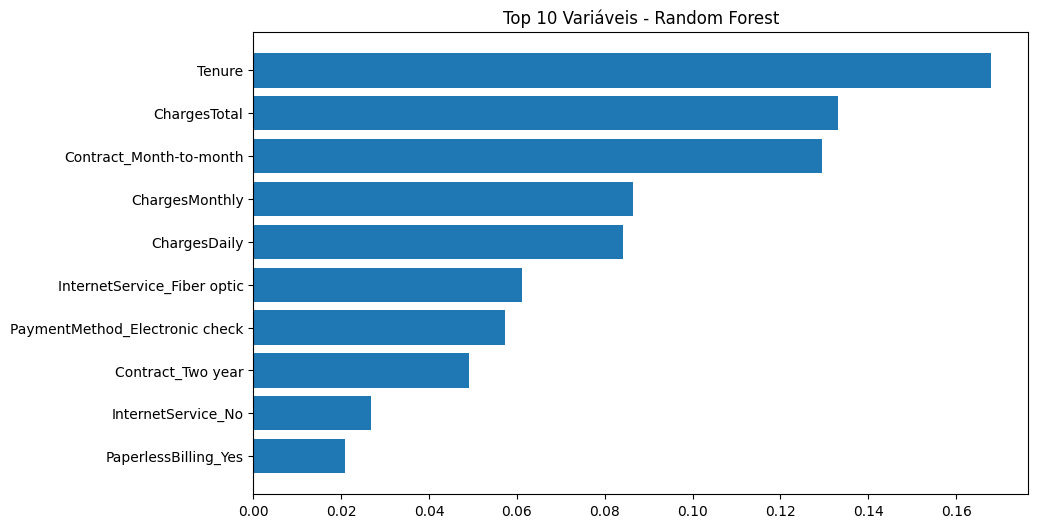

In [194]:

plt.figure(figsize=(10,6))
plt.barh(importancia_rf["Variável"][:10], importancia_rf["Importância"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Variáveis - Random Forest")
plt.show()

# **Árbol de decisión**

In [195]:


# Extraer importancias
importancias_arvore = tree_model.feature_importances_

# Creando DataFrame
df_arvore = pd.DataFrame({
    'Variavel': colunas,
    'Importancia': importancias_arvore
}).sort_values(by='Importancia', ascending=False)

df_arvore.head(10)



,Variavel,Importancia
15,Contract_Month-to-month,0.368331
23,Tenure,0.138140
26,ChargesTotal,0.114247
7,InternetService_Fiber optic,0.104430
25,ChargesMonthly,0.069434
24,ChargesDaily,0.031729
21,PaymentMethod_Electronic check,0.023610
5,MultipleLines_Yes,0.021736
6,InternetService_DSL,0.019824
0,Gender_Male,0.016281


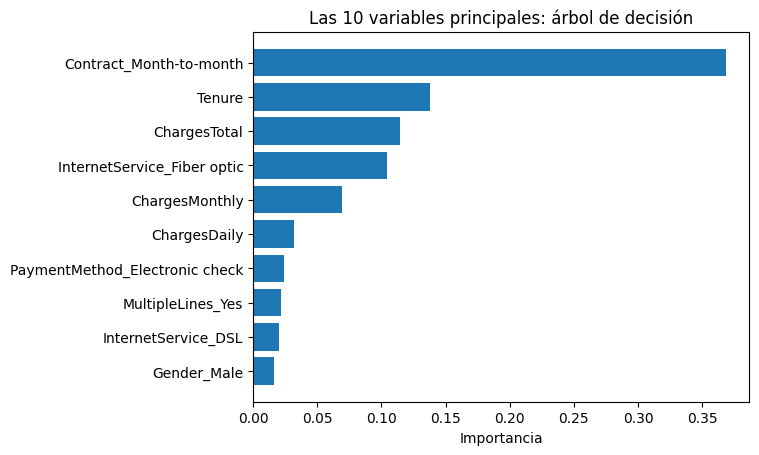

In [197]:

# Visualización con gráfico

plt.figure()
plt.barh(df_arvore['Variavel'][:10], df_arvore['Importancia'][:10])
plt.gca().invert_yaxis()
plt.title('Las 10 variables principales: árbol de decisión')
plt.xlabel('Importancia')
plt.show()

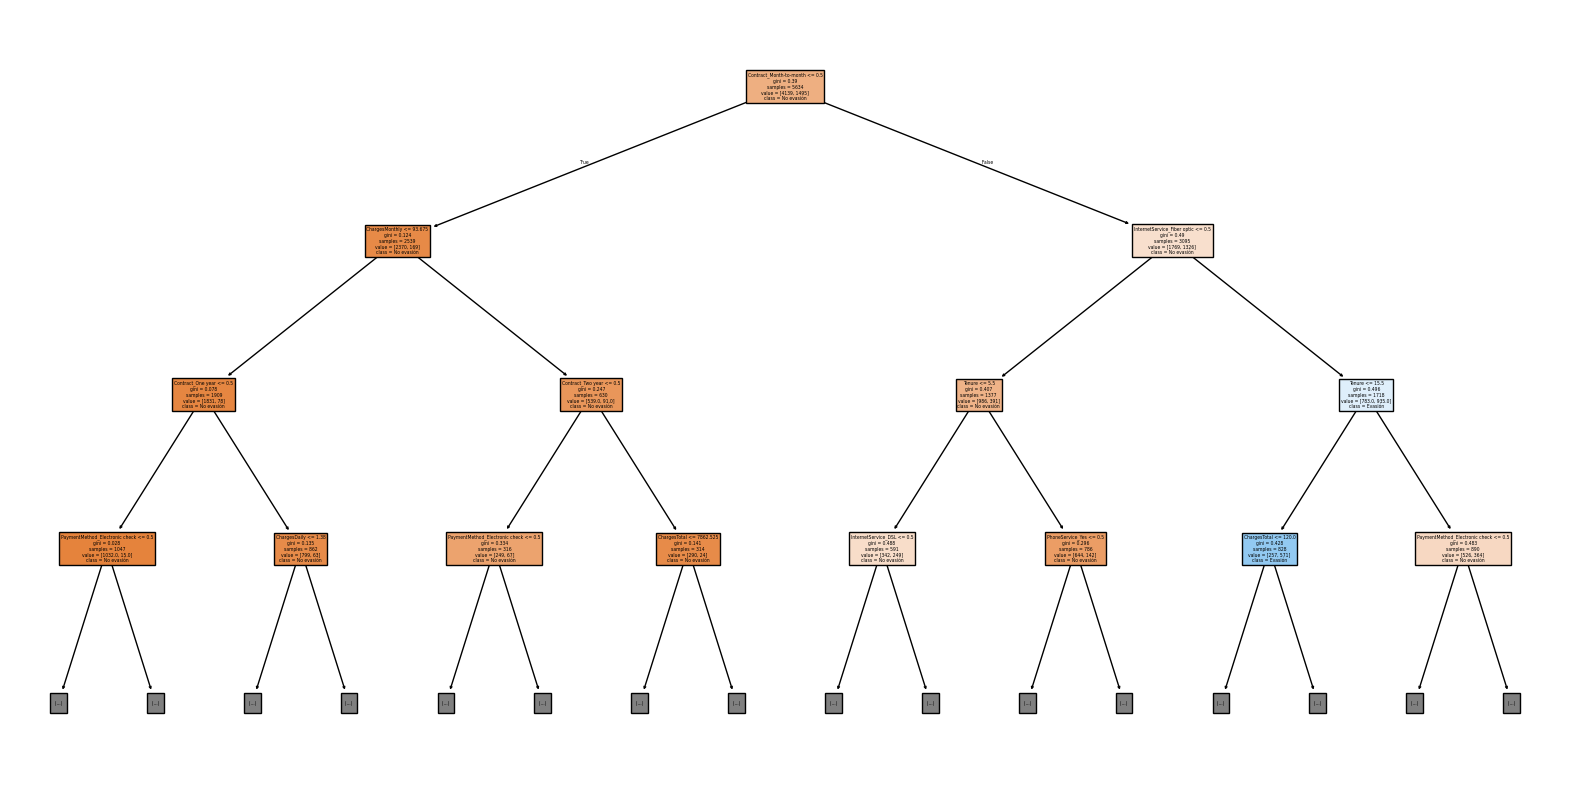

In [198]:

# Estructura del árbol
plt.figure(figsize=(20,10))
plot_tree(
    tree_model,
    feature_names=colunas,
    class_names=['No evasión', 'Evasión'],
    filled=True,
    max_depth=3
)
plt.show()


In [202]:
# Comparando la importancia del árbol de decisión con Random Forest

importancia_rf_renamed = importancia_rf.rename(columns={'Variável': 'Variavel', 'Importância': 'Importancia'})

comparacao = df_arvore.merge(
    importancia_rf_renamed,
    on='Variavel',
    suffixes=('_Arvore', '_RandomForest')
).sort_values(by='Importancia_Arvore', ascending=False)

comparacao.head(10)

,Variavel,Importancia_Arvore,Importancia_RandomForest
0,Contract_Month-to-month,0.368331,0.129426
1,Tenure,0.138140,0.168000
2,ChargesTotal,0.114247,0.133167
3,InternetService_Fiber optic,0.104430,0.061199
4,ChargesMonthly,0.069434,0.086512
5,ChargesDaily,0.031729,0.084205
6,PaymentMethod_Electronic check,0.023610,0.057276
7,MultipleLines_Yes,0.021736,0.011354
8,InternetService_DSL,0.019824,0.016538
9,Gender_Male,0.016281,0.011211


In [ ]:
El árbol de decisión muestra qué variables son decisivas para las primeras divisiones.

Si las variables importantes coinciden con el bosque aleatorio, esto refuerza su relevancia.

Si hay diferencias, puede indicar inestabilidad del árbol aislado (lo cual es de esperar, ya que el bosque aleatorio reduce la varianza al utilizar múltiples árboles).

In [203]:
# Comparando os modelos

# Regressão Logística
coef_log = pd.DataFrame({
    "Variável": colunas,
    "Logistica_Coef": log_model.coef_[0]
})

coef_log["Logistica_Impacto"] = np.abs(coef_log["Logistica_Coef"])


# Random Forest
rf_importancia = pd.DataFrame({
    "Variável": colunas,
    "RF_Importancia": rf_model.feature_importances_
})


# KNN (basado en la varianza tras la normalización)
variancia_knn = pd.DataFrame({
    "Variável": colunas,
    "KNN_Variancia": pd.DataFrame(x_treino_normalizado, columns=colunas).var()
})

# Unificando todo
comparacao_modelos = coef_log.merge(rf_importancia, on="Variável")
comparacao_modelos = comparacao_modelos.merge(variancia_knn, on="Variável")

# Ordenando por importância da Random Forest
comparacao_modelos = comparacao_modelos.sort_values(
    by="RF_Importancia",
    ascending=False
)

comparacao_modelos.head(15)

,Variável,Logistica_Coef,Logistica_Impacto,RF_Importancia,KNN_Variancia
23,Tenure,-0.053594,0.053594,0.168000,0.116571
26,ChargesTotal,0.000284,0.000284,0.133167,0.068749
15,Contract_Month-to-month,0.728986,0.728986,0.129426,0.247609
25,ChargesMonthly,0.011256,0.011256,0.086512,0.089511
24,ChargesDaily,0.006380,0.006380,0.084205,0.089257
7,InternetService_Fiber optic,0.437740,0.437740,0.061199,0.246737
21,PaymentMethod_Electronic check,0.321692,0.321692,0.057276,0.222202
17,Contract_Two year,-0.700963,0.700963,0.049047,0.183246
8,InternetService_No,-0.446523,0.446523,0.026694,0.168368
18,PaperlessBilling_Yes,0.346791,0.346791,0.020792,0.240582


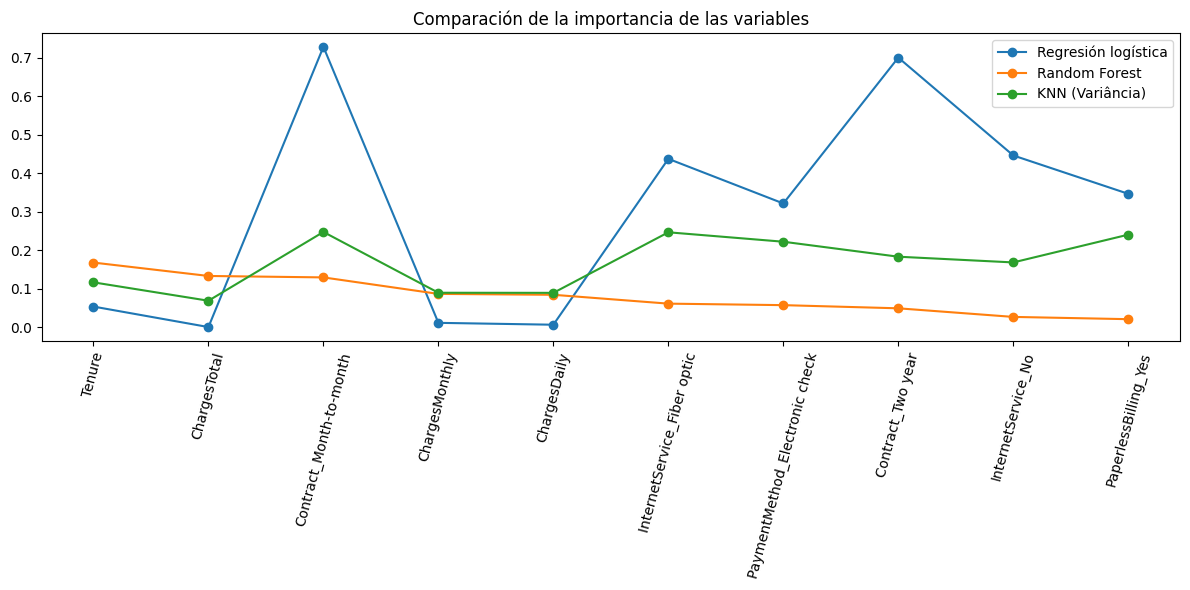

In [205]:

# Selección de las 10 variables principales del Random Forest
top_variaveis = comparacao_modelos.head(10)

plt.figure(figsize=(12,6))

plt.plot(top_variaveis["Variável"],
         top_variaveis["Logistica_Impacto"],
         marker='o', label="Regresión logística")

plt.plot(top_variaveis["Variável"],
         top_variaveis["RF_Importancia"],
         marker='o', label="Random Forest")

plt.plot(top_variaveis["Variável"],
         top_variaveis["KNN_Variancia"],
         marker='o', label="KNN (Variância)")

plt.xticks(rotation=75)
plt.legend()
plt.title("Comparación de la importancia de las variables")
plt.tight_layout()
plt.show()

# **Informe final**
El objetivo de este proyecto era desarrollar modelos de aprendizaje automático capaces de predecir la pérdida de clientes (churn), lo que permitiría a la empresa TelecomX anticipar comportamientos e implementar estrategias de retención.

Se evaluaron tres modelos:

- Regresión logística (log_model)
- KNN – K-Nearest Neighbors (knn_model)
- Random Forest (rf_model)


# **📈 Comparación general de los modelos**

**Regresión logística**

**✔ Puntos positivos**
- Modelo sencillo e interpretable.

- Permite el análisis directo de los coeficientes.

- Buen rendimiento para relaciones lineales.

- Fácil implementación y bajo coste computacional.

**✔ Interpretación**
- Los coeficientes muestran directamente el impacto de cada variable en la probabilidad de evasión, lo que facilita las decisiones estratégicas.

**❗ Limitación**
- Puede no captar relaciones complejas y no lineales entre variables.

# **KNN (K-vecinos más cercanos)**
**✔ Puntos positivos**
- Modelo intuitivo.
- No asume linealidad.
- Basado en la proximidad entre clientes similares.

**✔ Interpretación**
- La clasificación depende de los vecinos más cercanos en el espacio de características normalizado.

**❗ Limitaciones**
- Sensible a la escala de los datos.
- Alto coste computacional para bases grandes.
No proporciona la importancia directa de las variables.
Puede perder rendimiento en bases con muchas variables (alta dimensionalidad).

# **Bosque aleatorio**
**✔ Puntos positivos**
- Captura relaciones no lineales.
- Resistente al ruido y a los valores atípicos.
- Reduce el sobreajuste en comparación con un solo árbol.
- Proporciona la importancia de las variables.
- Excelente rendimiento predictivo.
**✔ Interpretación**
- El modelo calcula la importancia de las variables basándose en la reducción de la impureza en las divisiones de los árboles.

**✔ Ventaja estratégica**
- Identifica automáticamente interacciones complejas entre variables que los modelos lineales no capturan.

# **Mejor modelo: Random Forest.**

Basándonos en la comparación de métricas de rendimiento (precisión, recuperación, exactitud y puntuación F1) y en la capacidad de generalización observada en los datos de prueba, Random Forest (rf_model) destacó como el mejor modelo.

**🔎 Justificación técnica**

- Presentó el mejor equilibrio entre precisión y recuperación.
- Captura patrones no lineales presentes en el comportamiento de evasión.
- Demostró mayor solidez frente a la complejidad del conjunto de datos.
- Proporciona una clasificación de importancia de las variables, lo que permite un análisis estratégico.


# **Consideración importante sobre Recall**
En problemas de abandono, identificar correctamente a los clientes que se darán de baja (Recall de clase 1) es más importante que simplemente maximizar la precisión.

Random Forest presentó una mejor capacidad para identificar a los clientes con riesgo de abandono, lo que lo hace más adecuado para un uso estratégico.

# **Conclusión final**
Aunque la regresión logística ofrece una excelente interpretabilidad y el KNN proporciona un enfoque basado en la similitud, Random Forest presentó un mejor rendimiento general y una mayor capacidad para capturar patrones complejos en los datos.

Por lo tanto, se recomienda el uso de Random Forest como modelo final para la predicción de la evasión, que puede utilizarse para:

- Identificación de clientes de alto riesgo
- Creación de campañas de retención dirigidas
- Apoyo a la toma de decisiones estratégicas



> Añadir blockquote

